# Libraries

In [1]:
import os
os.chdir('..')

In [18]:
%load_ext autoreload
%autoreload 2
from dataset.toolwear import ExcelData, Toolwear
from pathlib import Path
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from tqdm import tqdm
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Real Data

In [3]:
NUM_CYCLE = 200
vib = Toolwear.batch_read(fpath=Path('D:/YandexDisk/machining/data/raw'), cut_no=1, kind='acc', n_cycle=NUM_CYCLE)
# vib = VibrationData.from_pickle(Path('D:/machining/data/raw/1/data.pickle'))

Batch File Read: 100%|█████████████████████████████████████████████████████████████████| 12/12 [00:11<00:00,  1.02it/s]


# Data Plot

In [4]:
subsets = [vib.make_subset_after(sec=start_sec) for start_sec in [1000, 1500,2000, 2500, 3000, 3500, 4000]]
# ax = vib.plot_3d(subsets, kind='fft')

In [76]:
subsets = [vib.reading.iloc[vib.second2index(sec0):vib.second2index(sec1),:] for sec0,sec1 in [(1000,2000),
                                                                                   (2000,3000),
                                                                                   (3000,4000),
                                                                                    (4000,5000),
                                                                                   (5000,6000)]]

In [23]:
import itertools
a = range(1,2)
b = ['a', 'b']
list(itertools.product(a,b))

[(1, 'a'), (1, 'b')]

In [20]:
subset_min = vib.reading['time'].iloc[0] # sec
subset_max = vib.reading['time'].iloc[-1] # sec
subset_len = 1 # sec
subset_stride = 0.2
print(f"Subset creation starting: [{subset_min}{subset_max}) stride:{subset_stride} len:{subset_len}")
subsets = [vib.reading.iloc[vib.second2index(sec0):vib.second2index(sec1),:] 
           for sec0,sec1 in zip(np.arange(subset_min, subset_max-subset_len+1, subset_stride), 
                                np.arange(subset_min+subset_len, subset_max+1, subset_stride))]

Subset creation starting: [0.06599.2498749999995) stride:0.2 len:1


Processing subsets..::   2%|█▎                                                   | 812/32997 [03:09<2:05:13,  4.28it/s]


KeyboardInterrupt: 

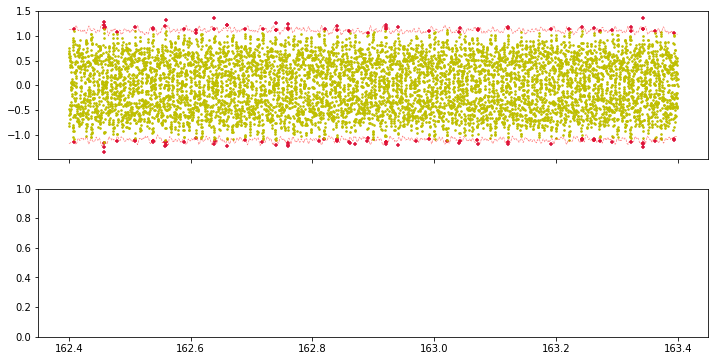

In [21]:
with tqdm(total=len(subsets), desc='Processing subsets..:') as pbar:
    for i, subset in enumerate(subsets):
        denoised_data = vib.denoise(subsets=subset, method='envelope', 
                                    threshold_epsilon=0.1, threshold_mul=1.,
                                    plot=True, figsize=(12,6),
                                    save=True, filename=f'denoised/denoised_{i}.jpg', 
                                    verbose=False)
        pbar.update(1)

In [16]:
from utils.plot_utils import image_folder_to_gif
image_folder_to_gif('denoised', glob='*.jpg')



Reading images..: 100%|██████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 15.57it/s]


In [154]:
str(Path('denoised').absolute()/'denoised.gif')

'C:\\Users\\ugur\\Documents\\GitHub\\ai-framework\\src\\denoised\\denoised.gif'

In [15]:
for _ in range(30): plt.close()

In [ ]:
denoised_data = vib.denoise(subsets=subsets[-1], method='savgol_difference', threshold_epsilon=2, plot=True)

In [ ]:
denoised_data = vib.denoise(subsets=subsets[0], method='envelope', threshold_mul=1.5, threshold_epsilon=2, plot=True)

In [ ]:
%matplotlib inline
vib.static_plot()

In [ ]:
ax = vib.plot_3d(subsets, kind='signal')

In [ ]:
START_SEC = 5000
# vib.apply_aggregation() # apply several filters
subset = vib.make_subset_after(sec=START_SEC)

# # # plot data
# vib.static_plot()
# vib.plot(plot=True, save=False)

# # plot fft
vib.fft(data=subset,
        plot=True)

# # plot spectrogram
# vib.spectrogram(data=subset,
#                 plot=True)

# plot wavelet
# vib.wavelet(data=subset, wavelet='cmor3-1.5',  clim=None, batch_size=8000*60*1, return_fig=True)

In [ ]:
vib.plot_toolwear()

# Envelope

In [ ]:
vib.envelope(subsets=subsets[-1], plot=True)

# Fake Data

In [ ]:
NUM_CYCLE =4
# read data
vib = VibrationData(path='',
                    rpm=5*10000, # create (rpm/60)*(n_flute) Hz vibration
                    sampling_freq=100000, n_cycle=NUM_CYCLE,
                    n_flute=3,
                       fake=True, add_noise=False)
vib.apply_aggregation() # apply several filters
subset = vib.make_subset_after(sec=1)
print(vib)
# vib.static_plot(save=False)
vib.plot(save=False)
# vib.fft(data=subset, plot=True, save=False)
# vib.spectrogram(data=subset, plot=True, save=False, engine='plotly')
ax, cwt = vib.wavelet(data=subset, wavelet='cgau5', save=False)


# Aux

In [ ]:
subset = vib.make_subset_after(sec=2.0)
colnames = ['data', 'lowpass', 'savgol', 'lowpass+savgol']
traces = [vib._make_trace(data=subset, colname=colname, mode='lines') for colname in colnames]
fig = go.FigureWidget(data=traces,
                      layout=go.Layout(xaxis={'title': 'Time(sec)'},
                                       yaxis={'title': 'Amplitude'},
                                       template=VibrationData.PLOT_TEMPLATE))

In [ ]:
fig.show()

In [ ]:
fig = vib.plot(subset)

In [ ]:
fig.data[0].name

In [ ]:
# load fig
fig = go.Figure("https://plot.ly/~jordanpeterson/889")

# find the range of the slider.
xmin, xmax = fig['layout']['xaxis']['range']

# create FigureWidget from fig
f = go.FigureWidget(data=fig.data, layout=fig.layout)

slider = widgets.FloatRangeSlider(
    min=xmin,
    max=xmax,
    step=(xmax - xmin) / 1000.0,
    readout=False,
    description='Time')
slider.layout.width = '800px'


# our function that will modify the xaxis range
def update_range(y):
    f.layout.xaxis.range = [y[0], y[1]]


# display the FigureWidget and slider with center justification
vb = VBox((f, interactive(update_range, y=slider)))
vb.layout.align_items = 'center'
vb

In [ ]:
import plotly.graph_objects as go

import pandas as pd

# Load data
df = pd.read_csv(
    "https://raw.githubusercontent.com/plotly/datasets/master/finance-charts-apple.csv")
df.columns = [col.replace("AAPL.", "") for col in df.columns]

# Create figure
fig = go.Figure()

fig.add_trace(
    go.Scatter(x=list(df.Date), y=list(df.High)))

# Set title
fig.update_layout(
    title_text="Time series with range slider and selectors"
)

# Add range slider
fig.update_layout(
    xaxis=dict(
#         rangeselector=dict(
#             buttons=list([
#                 dict(count=1,
#                      label="1m",
#                      step="month",
#                      stepmode="backward"),
#                 dict(count=6,
#                      label="6m",
#                      step="month",
#                      stepmode="backward"),
#                 dict(count=1,
#                      label="YTD",
#                      step="year",
#                      stepmode="todate"),
#                 dict(count=1,
#                      label="1y",
#                      step="year",
#                      stepmode="backward"),
#                 dict(step="all")
#             ])
#         ),
        rangeslider=dict(
            visible=True
        ),
        type="date"
    )
)

fig.show()

In [ ]:
x = widgets.IntText()
x

In [ ]:
x.value